In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ID_66.csv', sep=';')
df['date'] = pd.to_datetime(df[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))

# Sía gögnin fyrir tímabilið 1993-2023
gogn = (df['date'] >= '1993-10-01') & (df['date'] <= '2023-09-30')
df_30ar = df.loc[gogn].copy()

# Reikna meðaltal fyrir hvern mánuð
medaltalsar_manudir = df_30ar.groupby('MM').mean()
manudir_nofn = ['Jan', 'Feb', 'Mar', 'Apr', 'Maí', 'Jún', 'Júl', 'Ágú', 'Sep', 'Okt', 'Nóv', 'Des']
manudir = range(1, 13)

4.1 Árstíðarsveifla

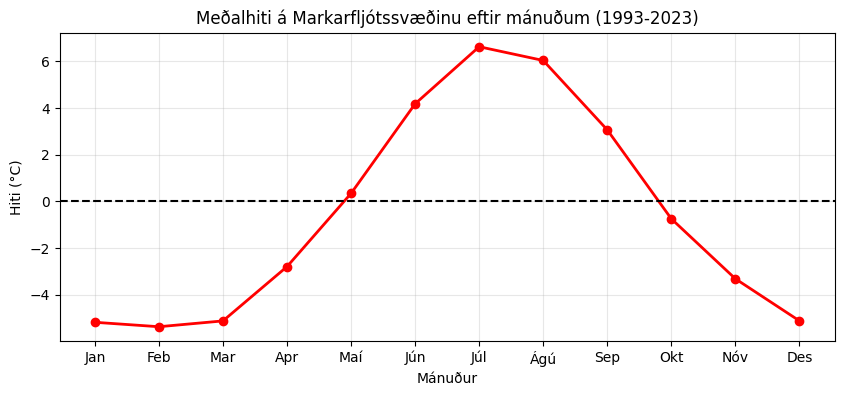

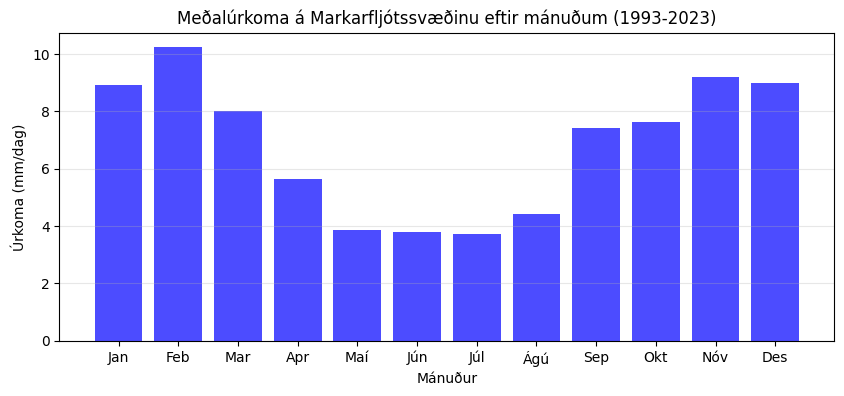

In [3]:
# Graf 1 - Hitastig
plt.figure(figsize=(10, 4))
plt.plot(manudir, medaltalsar_manudir['2m_temp_carra'], color='red', marker='o', linewidth=2)
plt.axhline(0, color='black', linestyle='--') # Frostmarkslína
plt.title('Meðalhiti á Markarfljótssvæðinu eftir mánuðum (1993-2023)')
plt.xlabel('Mánuður')
plt.ylabel('Hiti (°C)')
plt.xticks(manudir, manudir_nofn)
plt.grid(True, alpha=0.3)
plt.show()

# Graf 2 - Úrkoma
plt.figure(figsize=(10, 4))
plt.bar(manudir, medaltalsar_manudir['prec_carra'], color='blue', alpha=0.7)
plt.title('Meðalúrkoma á Markarfljótssvæðinu eftir mánuðum (1993-2023)')
plt.xlabel('Mánuður')
plt.ylabel('Úrkoma (mm/dag)')
plt.xticks(manudir, manudir_nofn)
plt.grid(axis='y', alpha=0.3)
plt.show()


In [4]:
import pandas as pd

# Lesa inn skrá
df_q = pd.read_csv('ID_66_q.csv', sep=';')

df_q['date'] = pd.to_datetime(df_q[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))

# Sía gögnin fyrir tímabilið 1993-2023
gogn_1 = (df_q['date'] >= '1993-10-01') & (df_q['date'] <= '2023-09-30')
df_30ar = df_q.loc[gogn_1].copy()

# Reikna meðaltal fyrir hvern mánuð
medaltalsar_manudir = df_30ar.groupby('MM').mean()
manudir_nofn = ['Jan', 'Feb', 'Mar', 'Apr', 'Maí', 'Jún', 'Júl', 'Ágú', 'Sep', 'Okt', 'Nóv', 'Des']
manudir = range(1, 13)

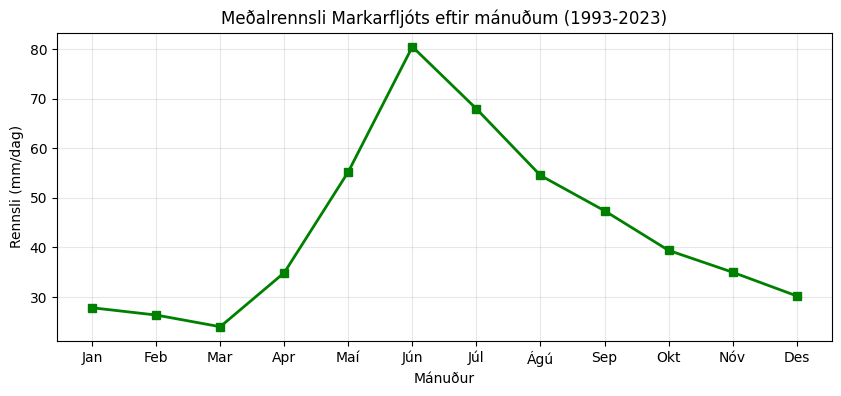

In [5]:
# Graf 3 - Rennsli
plt.figure(figsize=(10, 4))
plt.plot(manudir, medaltalsar_manudir['qobs'], color='green', marker='s', linewidth=2)
plt.title('Meðalrennsli Markarfljóts eftir mánuðum (1993-2023)')
plt.xlabel('Mánuður')
plt.ylabel('Rennsli (mm/dag)')
plt.xticks(manudir, manudir_nofn)
plt.grid(True, alpha=0.3)
plt.show()

4.2 Mat á grunnvatnsframlagi

In [6]:
import pandas as pd

# Lesa inn skrá
df_q = pd.read_csv('ID_66_q.csv', sep=';')

df_q['date'] = pd.to_datetime(df_q[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))

# 3. Sía gögnin fyrir tímabilið 1993-2023
gogn_1 = (df_q['date'] >= '1993-10-01') & (df_q['date'] <= '2023-09-30')
df_q_30ar = df_q.loc[gogn_1].copy()

print(df_q.columns.tolist())

['YYYY', 'MM', 'DD', 'qobs', 'qc_flag', 'date']


In [7]:

# Síustuðull
alpha = 0.925

# Búa til tóma dálka yfir yfirborðsrennnsli(yr) og grunnvatnsrennsli(gr) og fyllum svo inn í með for-lykkju
df_q_30ar['yr'] = 0.0  
df_q_30ar['gr'] = 0.0  

yr = 0 # upphafspunktur fyrir yfirborðsrennsli
for i in range(1, len(df_q_30ar)):
    # Notum qobs sem er mælt rennsli
    rennsli_i_dag = df_q_30ar['qobs'].iloc[i]
    rennsli_i_gaer = df_q_30ar['qobs'].iloc[i-1]
    
    yr = alpha * yr + ((1 + alpha) / 2) * (rennsli_i_dag - rennsli_i_gaer)
    
    # Passa að tölurnar séu raunhæfar (rennsli ekki undir 0 og að yr sé ekki hærri en heildarrennslið)
    yr = max(0, min(yr, rennsli_i_dag))
    
    df_q_30ar.iloc[i, df_q_30ar.columns.get_loc('yr')] = yr
    df_q_30ar.iloc[i, df_q_30ar.columns.get_loc('gr')] = rennsli_i_dag - yr

# 3. Reikna BFI 
heildar_rennsli = df_q_30ar['qobs'].sum()
heildar_gr = df_q_30ar['gr'].sum()
bfi = heildar_gr / heildar_rennsli

print(f'Heildarrennsli yfir tímabilið er: {round(heildar_rennsli,3)}')

print(f'Heildar grunnrennsli yfir tímabilið er: {round(heildar_gr,3)}')

print(f"Baseflow Index (BFI) fyrir Markarfljót er: {round(bfi, 3)}")

Heildarrennsli yfir tímabilið er: 478565.7
Heildar grunnrennsli yfir tímabilið er: 384967.378
Baseflow Index (BFI) fyrir Markarfljót er: 0.804


In [ ]:
# Recession analysis og recession constant
# Skoðum þá daga þar sem rennslið er að lækka (recession)
recession_dagar = df_q_30ar[df_q_30ar['qobs'] < df_q_30ar['qobs'].shift(1)]

# Recession constant k er hlutfallið á milli dagsins í dag og gærdagsins
k_gildi = recession_dagar['qobs'] / recession_dagar['qobs'].shift(1)
k_fasti = k_gildi.median()

print(f"Recession constant (k) er: {round(k_fasti, 3)}")

Recession constant (k) er: 0.97


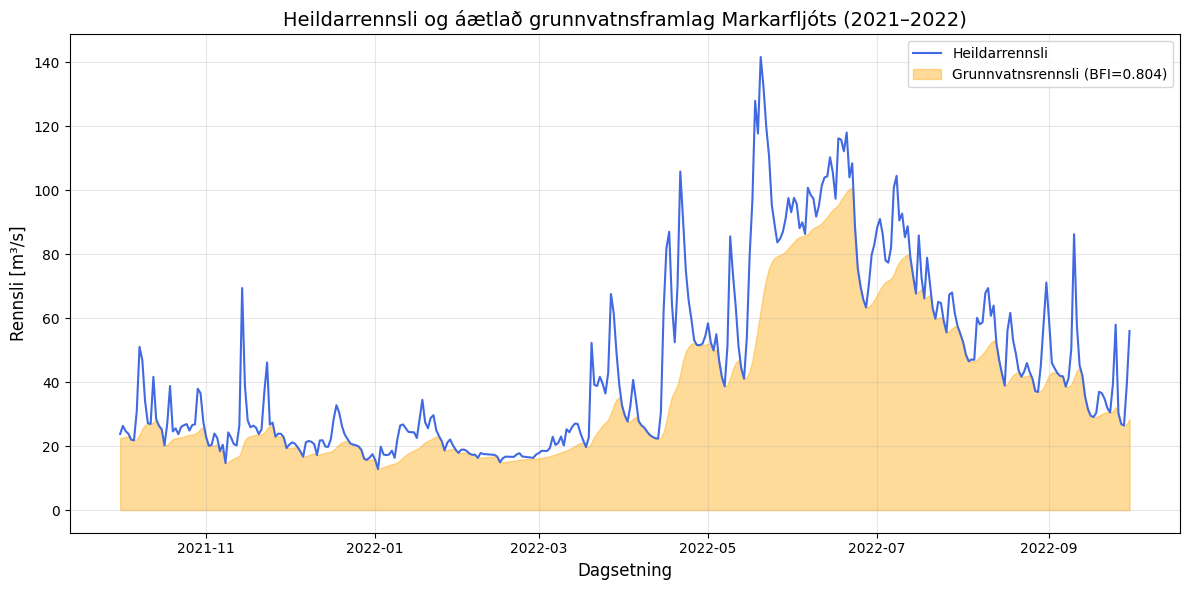

In [9]:
import matplotlib.pyplot as plt

# 1. Veljum eitt gott ár til að sýna (t.d. 2021)
dæmi = df_q_30ar[(df_q_30ar['date'] >= '2021-10-01') & (df_q_30ar['date'] <= '2022-09-30')]

plt.figure(figsize=(12, 6))

# Teikna heildarrennslið
plt.plot(dæmi['date'], dæmi['qobs'], label='Heildarrennsli', color='royalblue', linewidth=1.5)

# Setja inn grunnvatnrennslið og fylla fyrir neðan
plt.fill_between(dæmi['date'], dæmi['gr'], color='orange', alpha=0.4, label=f'Grunnvatnsrennsli (BFI=0.804)')

plt.title('Heildarrennsli og áætlað grunnvatnsframlag Markarfljóts (2021–2022)', fontsize=14)
plt.xlabel('Dagsetning', fontsize=12)
plt.ylabel('Rennsli [m³/s]', fontsize=12) # Athugaðu einingarnar þínar
plt.grid(alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

4.3 Tenging við grunnlíkingu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ID_66.csv', sep=';')
df['date'] = pd.to_datetime(df[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))

# Sía gögnin fyrir tímabilið 1993-2023
gogn = (df['date'] >= '1993-10-01') & (df['date'] <= '2023-09-30')
df_30ar = df.loc[gogn].copy()

# Reikna meðaltal fyrir hvern mánuð
medaltalsar_manudir = df_30ar.groupby('MM').mean()
manudir_nofn = ['Jan', 'Feb', 'Mar', 'Apr', 'Maí', 'Jún', 'Júl', 'Ágú', 'Sep', 'Okt', 'Nóv', 'Des']
manudir = range(1, 13)

In [2]:
import pandas as pd

# Lesa inn skrá
df_q = pd.read_csv('ID_66_q.csv', sep=';')

df_q['date'] = pd.to_datetime(df_q[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))


# Sía gögnin fyrir tímabilið 1993-2023
gogn_1 = (df_q['date'] >= '1993-10-01') & (df_q['date'] <= '2023-09-30')
df_30ar_1 = df_q.loc[gogn_1].copy()


# Reikna meðaltal fyrir hvern mánuð
medaltalsar_manudir_1 = df_30ar_1.groupby('MM').mean()
manudir_nofn = ['Jan', 'Feb', 'Mar', 'Apr', 'Maí', 'Jún', 'Júl', 'Ágú', 'Sep', 'Okt', 'Nóv', 'Des']
manudir = range(1, 13)

In [3]:
vatnasvid = 516  # km2

# Breytum qobs úr m3/s yfir í mm/dag
df_30ar_1['q_mm_dag'] = (df_30ar_1['qobs'] * 86400) / (vatnasvid * 1000)

medaltalsar_manudir_1 = df_30ar_1.groupby('MM').mean(numeric_only=True)

# Listi yfir fjölda daga í hverjum mánuði (janúar - desember)
dagar = [31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

# Við tökum meðaltal hvers mánaðar (mm/dag) og margföldum við fjölda daga í þeim mánuði
P_ar = sum(medaltalsar_manudir['prec_carra'] * dagar)
Q_ar = sum(medaltalsar_manudir_1['q_mm_dag'] * dagar)
E_ar = sum(medaltalsar_manudir['total_et'] * dagar)

print(f"Meðalúrkoma (P): {round(P_ar, 1)} mm/ár")
print(f"Meðalrennsli (Q): {round(Q_ar, 1)} mm/ár")
print(f"Meðaluppgufun (E): {round(E_ar, 1)} mm/ár")
print(f"Delta S: {round(P_ar - Q_ar - E_ar, 1)} mm/ár")

Meðalúrkoma (P): 2483.3 mm/ár
Meðalrennsli (Q): 2671.1 mm/ár
Meðaluppgufun (E): 132.0 mm/ár
Delta S: -319.8 mm/ár


4.4 Langæislína rennslis

Q5 (Hárennsli): 97.52 m3/s
Q50 (Miðgildi): 32.90 m3/s
Q95 (Lágrennsli): 16.10 m3/s


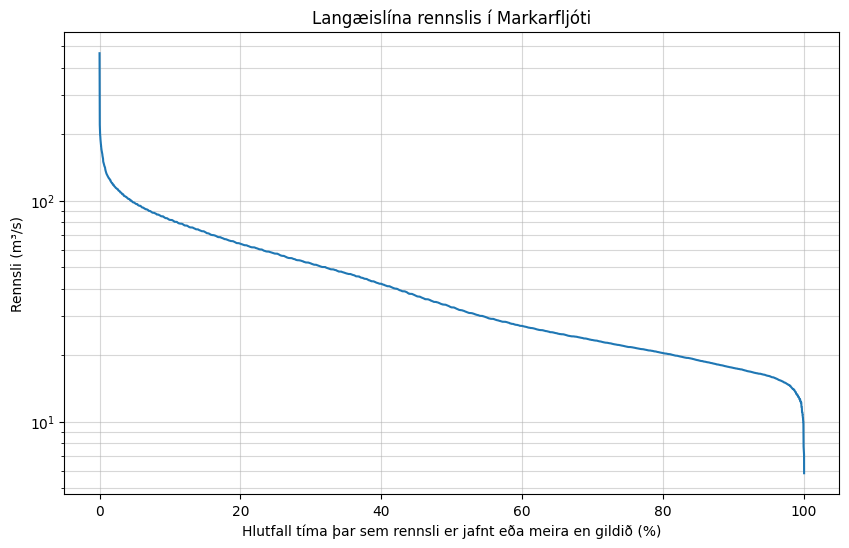

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lesa inn skrá
df_q = pd.read_csv('ID_66_q.csv', sep=';')

# Raða rennslinu frá hæsta til lægsta
gogn_2 = df_q['qobs'].sort_values(ascending=False).values

# Búum til röð frá 0 upp í 100 sem passar við fjölda mælinga
exceedance_prob = np.arange(1, len(gogn_2) + 1) / len(gogn_2) * 100

# Finna gildin Q5, Q50 og Q95
q5 = np.percentile(gogn_2, 95)   
q50 = np.percentile(gogn_2, 50) 
q95 = np.percentile(gogn_2, 5)   

print(f"Q5 (Hárennsli): {q5:.2f} m3/s")
print(f"Q50 (Miðgildi): {q50:.2f} m3/s")
print(f"Q95 (Lágrennsli): {q95:.2f} m3/s")

# Teikna myndina
plt.figure(figsize=(10, 6))
plt.plot(exceedance_prob, gogn_2)
plt.xlabel('Hlutfall tíma þar sem rennsli er jafnt eða meira en gildið (%)')
plt.ylabel('Rennsli (m³/s)')
plt.title('Langæislína rennslis í Markarfljóti')
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

4.5 Flóðagreining

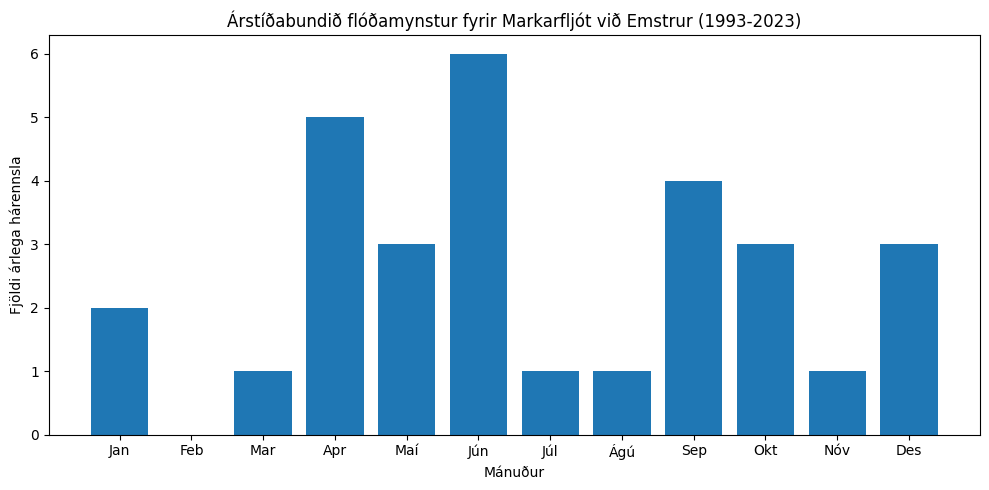

Fjöldi annual peaks notaður í tíðnigreiningu: 30

RMSE samanburður:
  Distribution       RMSE
0  LogPearson3   8.488883
1   LogNormal3   9.684391
2       Gumbel  30.137263

Besta dreifingin samkvæmt RMSE: LogPearson3

Q10, Q50, Q100:
   Endurkomutími í árum  Metið rennsli
0                    10     276.105760
1                    50     440.193433
2                   100     534.701992


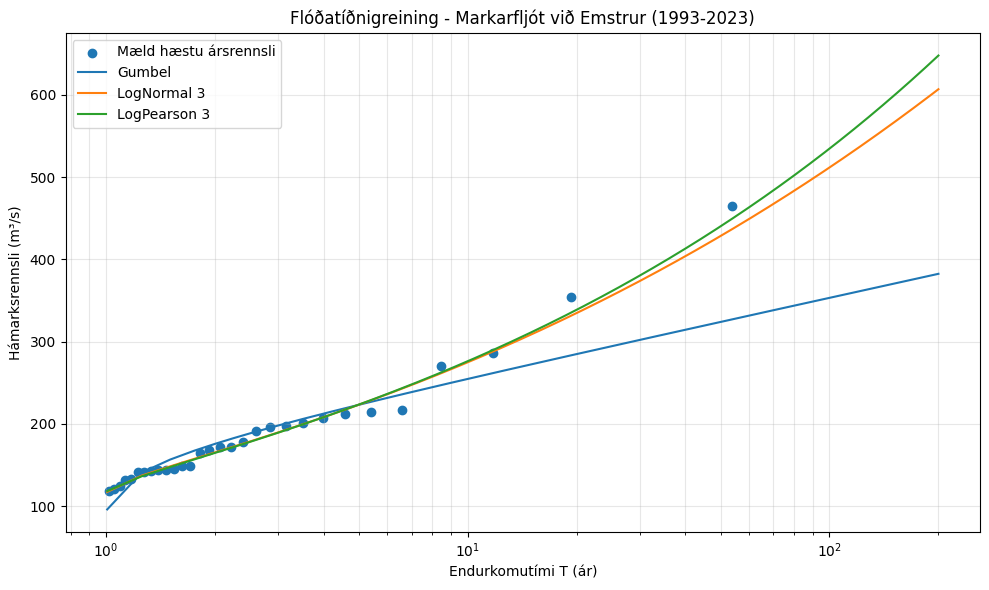

   Endurkomutími í árum  Metið rennsli   CI_5%  CI_95%
0                    10         276.11  221.66  336.83
1                    50         440.19  289.25  697.83
2                   100         534.70  318.21  959.46


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('ID_66_q.csv', sep=';')
df['date'] = pd.to_datetime(df[['YYYY', 'MM', 'DD']].rename(columns={'YYYY': 'year', 'MM': 'month', 'DD': 'day'}))

# Sía gögnin fyrir tímabilið 1993-2023
gogn = (df['date'] >= '1993-10-01') & (df['date'] <= '2023-09-30')
df_30ar = df.loc[gogn].copy()

# Reikna meðaltal fyrir hvern mánuð
medaltalsar_manudir = df_30ar.groupby('MM').mean()
manudir_nofn = ['Jan', 'Feb', 'Mar', 'Apr', 'Maí', 'Jún', 'Júl', 'Ágú', 'Sep', 'Okt', 'Nóv', 'Des']
manudir = range(1, 13)

# Búa til vatnaár
df_30ar['water_year'] = df_30ar['date'].apply(lambda x: x.year + 1 if x.month >= 10 else x.year)

# Finna annual peak fyrir hvert vatnaár
annual_peaks = df_30ar.loc[df_30ar.groupby('water_year')['qobs'].idxmax()].copy()
annual_peaks['peak_month'] = annual_peaks['date'].dt.month

# Telja mánuði
month_counts = annual_peaks['peak_month'].value_counts().sort_index()
month_counts = month_counts.reindex(range(1, 13), fill_value=0)

# Teikna
plt.figure(figsize=(10, 5))
plt.bar(range(1, 13), month_counts.values)
plt.xticks(range(1, 13), manudir_nofn)
plt.xlabel('Mánuður')
plt.ylabel('Fjöldi árlega hárennsla')
plt.title('Árstíðabundið flóðamynstur fyrir Markarfljót við Emstrur (1993-2023)')
plt.tight_layout()
plt.show()

# Annual peak gildi í lækkandi röð
peaks = np.sort(annual_peaks['qobs'].dropna().values)[::-1]
n = len(peaks)

if n < 10:
    raise ValueError("Of fá annual peaks til að gera áreiðanlega tíðnigreiningu.")

print(f"Fjöldi annual peaks notaður í tíðnigreiningu: {n}")

# Gringorten plotting positions
# m = rank í lækkandi röð
m = np.arange(1, n + 1)

# exceedance probability
p_exceed = (m - 0.44) / (n + 0.12)

# empirical return period
T_emp = 1 / p_exceed

# 3. Fit-a dreifingar
# Gumbel
gumbel_params = stats.gumbel_r.fit(peaks)

# Log Normal 3
ln3_params = stats.lognorm.fit(peaks)

# Log Pearson 3
# Fit-a Pearson III á log10(Q)
log_peaks = np.log10(peaks)
lp3_params = stats.pearson3.fit(log_peaks)

# Hjálparföll fyrir quantiles
def q_gumbel(T, params):
    p_nonexceed = 1 - 1 / np.asarray(T)
    loc, scale = params
    return stats.gumbel_r.ppf(p_nonexceed, loc=loc, scale=scale)

def q_ln3(T, params):
    p_nonexceed = 1 - 1 / np.asarray(T)
    shape, loc, scale = params
    return stats.lognorm.ppf(p_nonexceed, s=shape, loc=loc, scale=scale)

def q_lp3(T, params):
    p_nonexceed = 1 - 1 / np.asarray(T)
    skew, loc, scale = params
    qlog = stats.pearson3.ppf(p_nonexceed, skew=skew, loc=loc, scale=scale)
    return 10 ** qlog

# Fitted values fyrir empirical T
gumbel_fit = q_gumbel(T_emp, gumbel_params)
ln3_fit = q_ln3(T_emp, ln3_params)
lp3_fit = q_lp3(T_emp, lp3_params)

# RMSE til að velja bestu dreifingu
rmse_gumbel = np.sqrt(np.mean((peaks - gumbel_fit) ** 2))
rmse_ln3 = np.sqrt(np.mean((peaks - ln3_fit) ** 2))
rmse_lp3 = np.sqrt(np.mean((peaks - lp3_fit) ** 2))

rmse_table = pd.DataFrame({
    'Distribution': ['Gumbel', 'LogNormal3', 'LogPearson3'],
    'RMSE': [rmse_gumbel, rmse_ln3, rmse_lp3]
}).sort_values('RMSE').reset_index(drop=True)

print("\nRMSE samanburður:")
print(rmse_table)

best_dist = rmse_table.loc[0, 'Distribution']
print(f"\nBesta dreifingin samkvæmt RMSE: {best_dist}")

# Reikna Q10, Q50, Q100 úr bestu dreifingu
return_periods = np.array([10, 50, 100], dtype=float)

if best_dist == 'Gumbel':
    best_params = gumbel_params
    best_estimates = q_gumbel(return_periods, best_params)

elif best_dist == 'LogNormal3':
    best_params = ln3_params
    best_estimates = q_ln3(return_periods, best_params)

else:
    best_params = lp3_params
    best_estimates = q_lp3(return_periods, best_params)

q_table = pd.DataFrame({
    'Endurkomutími í árum': return_periods.astype(int),
    'Metið rennsli': best_estimates
})

print("\nQ10, Q50, Q100:")
print(q_table)

# Probability plot
T_plot = np.linspace(1.01, 200, 800)

plt.figure(figsize=(10, 6))
plt.scatter(T_emp, peaks, label='Mæld hæstu ársrennsli')
plt.plot(T_plot, q_gumbel(T_plot, gumbel_params), label='Gumbel')
plt.plot(T_plot, q_ln3(T_plot, ln3_params), label='LogNormal 3')
plt.plot(T_plot, q_lp3(T_plot, lp3_params), label='LogPearson 3')

plt.xscale('log')
plt.xlabel('Endurkomutími T (ár)')
plt.ylabel('Hámarksrennsli (m³/s)')
plt.title('Flóðatíðnigreining - Markarfljót við Emstrur (1993-2023)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Bootstrap fyrir 90% confidence interval
n_boot = 500
rng = np.random.default_rng(42)

boot_results = {
    10: [],
    50: [],
    100: []
}

for i in range(n_boot):
    sample = rng.choice(peaks, size=n, replace=True)
    sample = np.sort(sample)[::-1]

    try:
        if best_dist == 'Gumbel':
            params = stats.gumbel_r.fit(sample)
            boot_results[10].append(q_gumbel(10, params))
            boot_results[50].append(q_gumbel(50, params))
            boot_results[100].append(q_gumbel(100, params))

        elif best_dist == 'LogNormal3':
            params = stats.lognorm.fit(sample)
            boot_results[10].append(q_ln3(10, params))
            boot_results[50].append(q_ln3(50, params))
            boot_results[100].append(q_ln3(100, params))

        else:
            sample_log = np.log10(sample)
            params = stats.pearson3.fit(sample_log)
            boot_results[10].append(q_lp3(10, params))
            boot_results[50].append(q_lp3(50, params))
            boot_results[100].append(q_lp3(100, params))

    except Exception:
        continue

# Setja saman CI töflu
ci_rows = []

for T, est in zip([10, 50, 100], best_estimates):
    arr = np.array(boot_results[T])
    lower = np.percentile(arr, 5)
    upper = np.percentile(arr, 95)

    ci_rows.append({
        'Endurkomutími í árum': T,
        'Metið rennsli': est,
        'CI_5%': lower,
        'CI_95%': upper
    })

ci_table = pd.DataFrame(ci_rows)

print(ci_table.round(2))

4.6 Leitnigreining

Niðurstöður leitnigreiningar:
   period   n  sen_slope  intercept  p_value       trend  \
0  Annual  30     0.0503   -57.4909   0.5559    no trend   
1   Vetur  30    -0.0365    99.4087   0.7753    no trend   
2     Vor  30     0.4779  -922.8988   0.0005  increasing   
3   Sumar  30     0.1103  -154.1394   0.7753    no trend   
4   Haust  31    -0.0241    90.0009   0.8918    no trend   

   significant_p_lt_0_05  
0                  False  
1                  False  
2                   True  
3                  False  
4                  False  


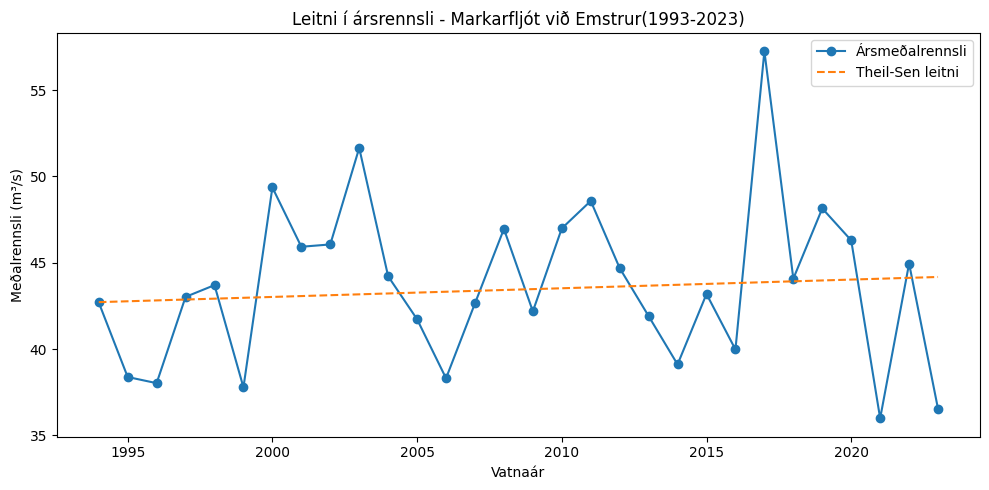

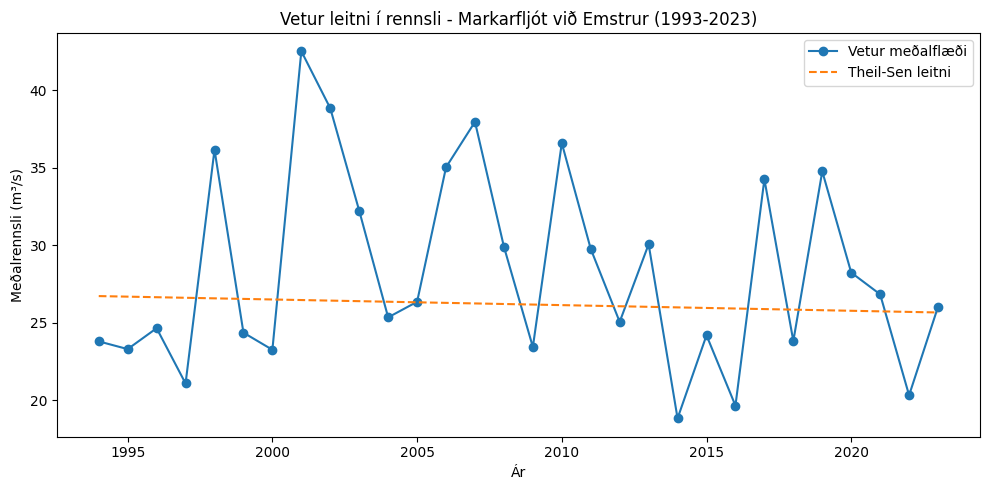

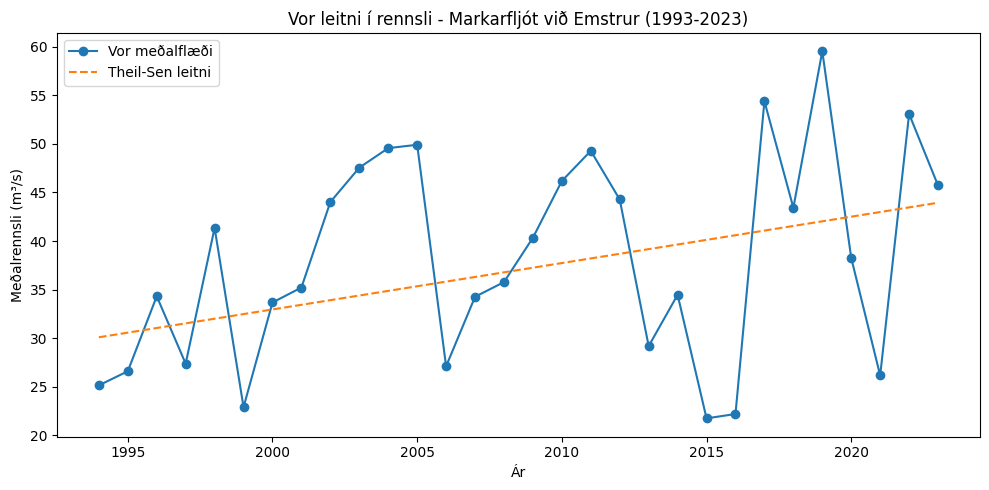

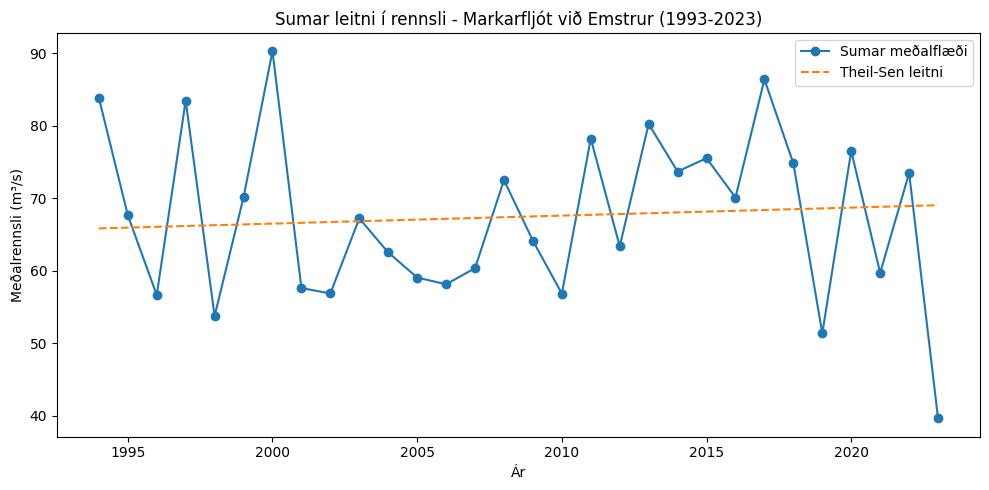

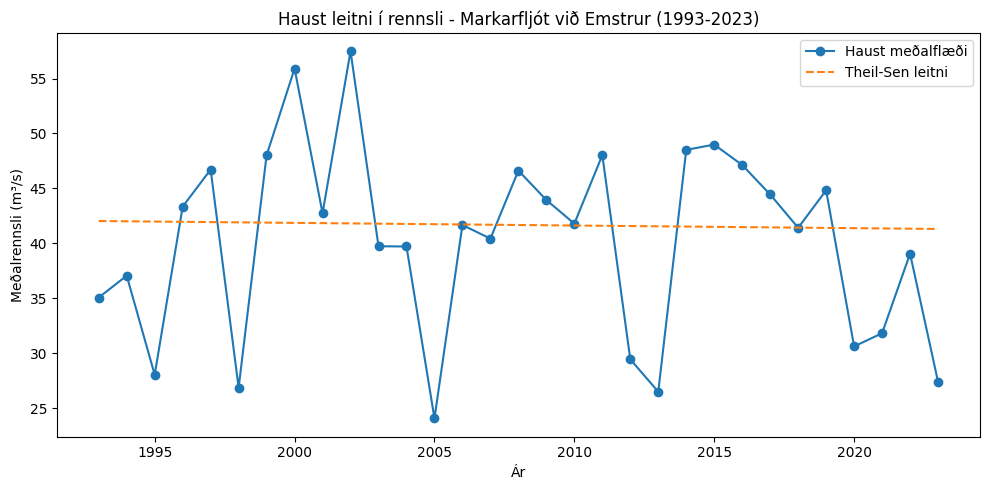

   period   n  sen_slope  p_value       trend  significant_p_lt_0_05
0  Annual  30      0.050   0.5559    no trend                  False
1   Vetur  30     -0.036   0.7753    no trend                  False
2     Vor  30      0.478   0.0005  increasing                   True
3   Sumar  30      0.110   0.7753    no trend                  False
4   Haust  31     -0.024   0.8918    no trend                  False


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import theilslopes
import pymannkendall as mk

df = pd.read_csv("ID_66_q.csv", sep=";")

df["date"] = pd.to_datetime(
    df[["YYYY", "MM", "DD"]].rename(
        columns={"YYYY": "year", "MM": "month", "DD": "day"}
    )
)

# Velja tímabilið 1993-10-01 til 2023-09-30
mask = (df["date"] >= "1993-10-01") & (df["date"] <= "2023-09-30")
df = df.loc[mask].copy()

df = df.dropna(subset=["qobs"])
df = df[df["qobs"] >= 0].copy()

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# Vatnaár: okt-sept
df["water_year"] = np.where(df["month"] >= 10, df["year"] + 1, df["year"])

# Árstíðir
def season_from_month(m):
    if m in [12, 1, 2]:
        return "Vetur"
    elif m in [3, 4, 5]:
        return "Vor"
    elif m in [6, 7, 8]:
        return "Sumar"
    else:
        return "Haust"

df["season"] = df["month"].apply(season_from_month)

# "Season year" svo desember fari með jan-feb í sama vetur
df["season_year"] = df["year"]
df.loc[df["month"] == 12, "season_year"] = df.loc[df["month"] == 12, "year"] + 1

# Ársmeðalrennsli
annual = (
    df.groupby("water_year", as_index=False)["qobs"]
    .mean()
    .rename(columns={"qobs": "mean_flow"})
)

# Árstíðameðalrennsli
seasonal = (
    df.groupby(["season_year", "season"], as_index=False)["qobs"]
    .mean()
    .rename(columns={"qobs": "mean_flow"})
)

# Pivot svo hver árstíð verði sér dálkur
seasonal_wide = seasonal.pivot(index="season_year", columns="season", values="mean_flow").reset_index()

# Fall fyrir Theil-Sen + modified Mann-Kendall
def trend_analysis(x, y, label):
    """
    x = tími (ár)
    y = rennsli
    """
    temp = pd.DataFrame({"x": x, "y": y}).dropna().copy()

    if len(temp) < 8:
        return {
            "period": label,
            "n": len(temp),
            "sen_slope": np.nan,
            "intercept": np.nan,
            "p_value": np.nan,
            "trend": "Too few data",
            "significant_p_lt_0_05": False
        }

    # Theil-Sen slope
    slope, intercept, low_slope, high_slope = theilslopes(temp["y"], temp["x"], 0.95)

    # Modified Mann-Kendall
    mk_result = mk.hamed_rao_modification_test(temp["y"])

    return {
        "period": label,
        "n": len(temp),
        "sen_slope": slope,
        "intercept": intercept,
        "p_value": mk_result.p,
        "trend": mk_result.trend,
        "significant_p_lt_0_05": bool(mk_result.p < 0.05)
    }

results = []

# Ár
results.append(
    trend_analysis(
        annual["water_year"],
        annual["mean_flow"],
        "Annual"
    )
)

# Árstíðir
for season_name in ["Vetur", "Vor", "Sumar", "Haust"]:
    if season_name in seasonal_wide.columns:
        results.append(
            trend_analysis(
                seasonal_wide["season_year"],
                seasonal_wide[season_name],
                season_name
            )
        )

results_df = pd.DataFrame(results)

print("Niðurstöður leitnigreiningar:")
print(results_df.round(4))

results_df.to_csv("trend_analysis_results_ID66.csv", index=False)

# Plot-a annual trend
annual_clean = annual.dropna(subset=["mean_flow"]).copy()
annual_result = results_df.loc[results_df["period"] == "Annual"].iloc[0]

x_ann = annual_clean["water_year"].values
y_ann = annual_clean["mean_flow"].values

trend_line_ann = annual_result["intercept"] + annual_result["sen_slope"] * x_ann

plt.figure(figsize=(10, 5))
plt.plot(x_ann, y_ann, marker="o", linestyle="-", label="Ársmeðalrennsli")
plt.plot(x_ann, trend_line_ann, linestyle="--", label="Theil-Sen leitni")
plt.xlabel("Vatnaár")
plt.ylabel("Meðalrennsli (m³/s)")
plt.title("Leitni í ársrennsli - Markarfljót við Emstrur(1993-2023)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot-a árstíðir
for season_name in ["Vetur", "Vor", "Sumar", "Haust"]:
    if season_name not in seasonal_wide.columns:
        continue

    temp = seasonal_wide[["season_year", season_name]].dropna().copy()
    row = results_df.loc[results_df["period"] == season_name].iloc[0]

    x = temp["season_year"].values
    y = temp[season_name].values
    trend_line = row["intercept"] + row["sen_slope"] * x

    plt.figure(figsize=(10, 5))
    plt.plot(x, y, marker="o", linestyle="-", label=f"{season_name} meðalflæði")
    plt.plot(x, trend_line, linestyle="--", label="Theil-Sen leitni")
    plt.xlabel("Ár")
    plt.ylabel("Meðalrennsli (m³/s)")
    plt.title(f"{season_name} leitni í rennsli - Markarfljót við Emstrur (1993-2023)")
    plt.legend()
    plt.tight_layout()
    plt.show()

report_table = results_df.copy()
report_table["sen_slope"] = report_table["sen_slope"].round(3)
report_table["p_value"] = report_table["p_value"].round(4)

print(report_table[["period", "n", "sen_slope", "p_value", "trend", "significant_p_lt_0_05"]])

4.7 Greining á rennslisatburði

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

q_file = "ID_66_q.csv"    
met_file = "ID_66.csv"    

start_date = "1993-10-01"
end_date   = "2023-09-30"

# Velja hvaða annual peak atburð á að skoða:
# 1 = stærsta flóðið, 2 = næststærsta o.s.frv.
event_rank = 1

# Gluggi fyrir myndina
days_before_peak = 10
days_after_peak = 10

# Þröskuldar fyrir skilgreiningar
precip_threshold = 1.0     # mm/dag, til að meta "úrkoma lokið"
return_tolerance = 0.05    # 5% frá grunnástandi

# Lesa rennsli
q = pd.read_csv(q_file, sep=";")
q["date"] = pd.to_datetime(
    q[["YYYY", "MM", "DD"]].rename(
        columns={"YYYY": "year", "MM": "month", "DD": "day"}
    )
)

if "qobs" not in q.columns:
    raise ValueError("Rennslisskráin inniheldur ekki dálkinn 'qobs'.")

q = q[["date", "qobs"]].copy()
q = q.rename(columns={"qobs": "Q"})
q = q.dropna(subset=["Q"])
q = q[q["Q"] >= 0].copy()

# Lesa veðurgögn
met = pd.read_csv(met_file, sep=";")
met["date"] = pd.to_datetime(
    met[["YYYY", "MM", "DD"]].rename(
        columns={"YYYY": "year", "MM": "month", "DD": "day"}
    )
)

# Reyna að finna úrkomu- og hitadálk sjálfvirkt
possible_precip = [
    "prec", "pr", "precip", "precipitation", "P",
    "tot_prec", "total_precip", "tp"
]

possible_temp = [
    "2m_temp_max", "2m_temp_mean", "2m_temp",
    "temp", "tmean", "tavg", "ta", "T",
    "t2m", "tas"
]

precip_col = None
temp_col = None

for c in possible_precip:
    if c in met.columns:
        precip_col = c
        break

for c in possible_temp:
    if c in met.columns:
        temp_col = c
        break

# Ef sjálfvirk leit finnur ekki dálkana:
if precip_col is None or temp_col is None:
    raise ValueError(
        "Fann ekki sjálfkrafa úrkomu- eða hitadálk í veðurskránni.\n"
        "Athugaðu print(met.columns.tolist()) og settu nöfnin handvirkt í kóðanum."
    )

met = met[["date", precip_col, temp_col]].copy()
met = met.rename(columns={precip_col: "P", temp_col: "T"})

# Sameina gögn og sía tímabil
df = pd.merge(q, met, on="date", how="inner")
df = df[(df["date"] >= start_date) & (df["date"] <= end_date)].copy()
df = df.sort_values("date").reset_index(drop=True)

# Finna annual peaks
df["water_year"] = np.where(df["date"].dt.month >= 10,
                            df["date"].dt.year + 1,
                            df["date"].dt.year)

annual_peaks = df.loc[df.groupby("water_year")["Q"].idxmax()].copy()
annual_peaks = annual_peaks.sort_values("Q", ascending=False).reset_index(drop=True)

print("\n5 stærstu annual peaks:")
print(annual_peaks[["water_year", "date", "Q"]].head(5))

if event_rank < 1 or event_rank > len(annual_peaks):
    raise ValueError("event_rank er utan marka.")

event = annual_peaks.iloc[event_rank - 1]
peak_date = event["date"]
Q_peak = event["Q"]

print(f"\nValinn atburður: rank {event_rank}")
print(f"Dagsetning topps: {peak_date.date()}")
print(f"Qpeak: {Q_peak:.2f}")

# Velja glugga í kringum atburð
window_start = peak_date - pd.Timedelta(days=days_before_peak)
window_end   = peak_date + pd.Timedelta(days=days_after_peak)

event_df = df[(df["date"] >= window_start) & (df["date"] <= window_end)].copy()
event_df = event_df.reset_index(drop=True)

if event_df.empty:
    raise ValueError("Atburðarglugginn er tómur.")

# Finna upphaf atburðar
# Skilgreining: lægsta Q frá upphafi gluggans fram að toppdegi
pre_peak = event_df[event_df["date"] <= peak_date].copy()
start_idx = pre_peak["Q"].idxmin()
event_start_date = event_df.loc[start_idx, "date"]
Q_start = event_df.loc[start_idx, "Q"]

# grunnástand = Q í upphafi atburðar
baseline_Q = Q_start
return_level = baseline_Q * (1 + return_tolerance)

# Finna lok úrkomu
# Skilgreining: síðasti dagur með P > precip_threshold, innan gluggans fram að toppi eða stuttu eftir topp
precip_search_end = peak_date + pd.Timedelta(days=2)
precip_period = event_df[event_df["date"] <= precip_search_end].copy()
rain_days = precip_period[precip_period["P"] > precip_threshold]

if len(rain_days) > 0:
    rain_end_date = rain_days["date"].max()
else:
    rain_end_date = event_start_date  # fallback

# Finna recovery date
# Skilgreining: fyrsti dagur eftir peak þar sem Q <= return_level
post_peak = event_df[event_df["date"] >= peak_date].copy()
recovered = post_peak[post_peak["Q"] <= return_level]

if len(recovered) > 0:
    recovery_date = recovered["date"].iloc[0]
else:
    recovery_date = event_df["date"].iloc[-1]  # fallback ef nær sér ekki innan gluggans

# Reikna tímalengdir
time_to_peak_days = (peak_date - event_start_date).days
excess_rain_release_days = (recovery_date - rain_end_date).days
recession_time_days = (recovery_date - peak_date).days

print("\nTímalengdir:")
print(f"Time-to-peak: {time_to_peak_days} dagar")
print(f"Excess rain release time: {excess_rain_release_days} dagar")
print(f"Recession time: {recession_time_days} dagar")




# P á hægri ás
ax2 = ax1.twinx()
ax2.bar(event_df["date"], event_df["P"], alpha=0.35, width=0.8, label="P (úrkoma)")
ax2.plot(event_df["date"], event_df["T"], marker="s", linestyle="-", label="T (hiti)")
ax2.set_ylabel("P / T")

# Sameina legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# Textabox
textstr = (
    f"Qpeak = {Q_peak:.2f}\n"
    f"Time-to-peak = {time_to_peak_days} dagar\n"
    f"Excess rain release time = {excess_rain_release_days} dagar\n"
    f"Recession time = {recession_time_days} dagar"
)

fig, axes = plt.subplots(
    3, 1, figsize=(13, 9), sharex=True,
    gridspec_kw={"height_ratios": [2, 1, 1]}
)

# Q

ax = axes[0]
ax.plot(event_df["date"], event_df["Q"], marker="o", label="Q (rennsli)")
ax.set_ylabel("Rennsli")
ax.set_title("Rennslisatburður - Markarfljót við Emstrur (1993-2023)")

# lykildagsetningar
for d, label, style in [
    (event_start_date, "Upphaf atburðar", "--"),
    (peak_date, "Flóðtoppur", "--"),
    (rain_end_date, "Lok úrkomu", ":"),
    (recovery_date, "Endurheimt", "--")
]:
    ax.axvline(d, linestyle=style, linewidth=1.2, label=label)

# viðmið
ax.axhline(baseline_Q, linestyle=":", linewidth=1.0, label="Upphafs-Q")
ax.axhline(return_level, linestyle=":", linewidth=1.0, label="Endurheimtarmörk")

# texti
textstr = (
    f"Flóðtoppur = {Q_peak:.1f}\n"
    f"Tími að toppi = {time_to_peak_days} dagar\n"
    f"Losunartími umframúrkomu = {excess_rain_release_days} dagar\n"
    f"Afturhvarfstími = {recession_time_days} dagar"
)
ax.text(
    0.02, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    fontsize=10
)

# P
ax = axes[1]
ax.bar(event_df["date"], event_df["P"], label="P (úrkoma)", alpha=0.7)
ax.set_ylabel("Úrkoma")

for d, style in [
    (event_start_date, "--"),
    (peak_date, "--"),
    (rain_end_date, ":"),
    (recovery_date, "--")
]:
    ax.axvline(d, linestyle=style, linewidth=1.2)

# T
ax = axes[2]
ax.plot(event_df["date"], event_df["T"], marker="s", label="T (hiti)")
ax.set_ylabel("Hitastig")
ax.set_xlabel("Dagsetning")

for d, style in [
    (event_start_date, "--"),
    (peak_date, "--"),
    (rain_end_date, ":"),
    (recovery_date, "--")
]:
    ax.axvline(d, linestyle=style, linewidth=1.2)

ax.axhline(0, linestyle=":", linewidth=1.0)
ax.legend(loc="upper left")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

summary.to_csv("event_analysis_summary_ID66.csv", index=False)
event_df.to_csv("event_window_ID66.csv", index=False)


5 stærstu annual peaks:
   water_year       date       Q
0        2007 2006-12-20  465.37
1        2002 2002-01-10  353.69
2        2003 2002-11-28  286.25
3        2005 2005-04-19  270.10
4        2010 2010-01-20  216.47

Valinn atburður: rank 1
Dagsetning topps: 2006-12-20
Qpeak: 465.37

Tímalengdir:
Time-to-peak: 5 dagar
Excess rain release time: 8 dagar
Recession time: 10 dagar


NameError: name 'ax1' is not defined